In [1]:
# ============================================================
# CELL 0 — GLOBAL IMPORTS + PATH DETECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
import os
from pathlib import Path

# ----------------------------
# AUTO-DETECT OPEN EPHYS ROOT
# ----------------------------

# You only specify the kilosort folder#######################################################################################################################################################################################################
kilosort_path = Path(
    r"C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"
)

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find session root containing 'Record Node ...'")
        if any("Record Node" in d for d in os.listdir(parent)):
            return parent
        path = parent

raw_data_path = find_session_root(kilosort_path)
print("Detected session root:", raw_data_path)

# Analyzer output folder
analyzer_path = raw_data_path / "sorting_analyzer_output"
analyzer_path.mkdir(exist_ok=True)
print("Analyzer output folder:", analyzer_path)


Detected session root: C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49
Analyzer output folder: C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\sorting_analyzer_output


In [2]:
# ============================================================
# CELL 1 — VERIFY + LOAD RECORDING
# ============================================================

print("\n=== PATH VERIFICATION ===")
print("Session folder exists:", raw_data_path.is_dir())

record_nodes = [f for f in os.listdir(raw_data_path) if "Record Node" in f]
print("Record Nodes found:", record_nodes)

for rn in record_nodes:
    oebin_path = raw_data_path / rn / "experiment1" / "recording1" / "structure.oebin"
    print(f"Checking {oebin_path}: exists =", oebin_path.is_file())

print("\nLoading Neuropixels stream...")
recording = si.read_openephys(raw_data_path, stream_id='0')
recording = si.scale(recording)

print("Loaded recording:")
print(recording)
print("Sampling rate:", recording.sampling_frequency)
print("Num channels:", recording.get_num_channels())



=== PATH VERIFICATION ===
Session folder exists: True
Record Nodes found: ['Record Node 101', 'Record Node 104']
Checking C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 101\experiment1\recording1\structure.oebin: exists = True
Checking C:\Users\Shermanlab\Desktop\2026-03-02_14-04-49\Record Node 104\experiment1\recording1\structure.oebin: exists = True

Loading Neuropixels stream...
Loaded recording:
ScaleRecording: 384 channels - 30.0kHz - 1 segments - 68,282,811 samples 
                2,276.09s (37.93 minutes) - float32 dtype - 97.68 GiB
Sampling rate: 30000.0
Num channels: 384


In [3]:
# ============================================================
# CELL 2 — CREATE ANALYZER + FEATURE EXTRACTION (run once)
# ============================================================

print("Loading sorting...")
sorting = si.read_kilosort(kilosort_path)

print("Creating analyzer...")

analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording,
    folder=analyzer_path,
    format="binary_folder",
    overwrite=True
)

print("Computing FEATURES (run once)...")

analyzer.compute("random_spikes", max_spikes_per_unit=300)
analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0)
analyzer.compute("noise_levels")

print("Feature extraction complete and cached.")


Loading sorting...
Creating analyzer...


estimate_sparsity (no parallelization):   0%|          | 0/2277 [00:00<?, ?it/s]

Computing FEATURES (run once)...


compute_waveforms (no parallelization):   0%|          | 0/2277 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

Feature extraction complete and cached.


In [9]:
# ============================================================
# CELL 3 — LOAD CACHED FEATURES (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Loading cached SpikeInterface features...")

# --- Verify analyzer exists ---
try:
    analyzer
except NameError:
    raise RuntimeError("ERROR: 'analyzer' is not defined. "
                       "Did you run Cell 2 (feature extraction) first?")

# --- Load SI extensions (waveforms + noise only) ---
try:
    wfs_ext = analyzer.get_extension("waveforms")
    noise_ext = analyzer.get_extension("noise_levels")
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to load one or more extensions: {e}")

# --- Extract noise levels (SI is correct for this) ---
try:
    noise = noise_ext.get_data()   # shape: (n_channels,)
except Exception as e:
    raise RuntimeError(f"ERROR: Failed to extract noise data: {e}")

# ============================================================
# LOAD KILOSORT TEMPLATES + CHANNEL MAP + PHY CLUSTER INFO
# ============================================================

import pandas as pd

ks_templates = np.load(kilosort_path / "templates.npy")          # (n_units, n_samples, n_channels)
ks_channel_map = np.load(kilosort_path / "channel_map.npy")      # physical channel ID per template channel index
cluster_info = pd.read_csv(kilosort_path / "cluster_info.tsv", sep="\t")

print("\n=== FEATURE LOAD SUMMARY ===")
print("Kilosort templates shape:", ks_templates.shape)
print("Noise array shape:", noise.shape)
print("Number of units:", len(sorting.unit_ids))

# --- Build mapping: unit_id → Phy main channel ID ---
cluster_col = "cluster_id" if "cluster_id" in cluster_info.columns else "id"
channel_col = "ch" if "ch" in cluster_info.columns else "channel"

phy_best_ch_id = {
    int(row[cluster_col]): int(row[channel_col])
    for _, row in cluster_info.iterrows()
}

# ============================================================
# UNWHITEN KILOSORT TEMPLATES
# ============================================================

# Load Kilosort inverse whitening matrix
whitening_inv = np.load(kilosort_path / "whitening_mat_inv.npy")   # shape (384, 384)

# Apply unwhitening: (n_units, n_samples, n_channels)
ks_templates_unwhitened = np.einsum("ij,utj->uti", whitening_inv, ks_templates)

print("Unwhitened templates shape:", ks_templates_unwhitened.shape)

# --- Build mapping: physical channel ID → template channel index ---
phys_to_template_index = {phys_id: idx for idx, phys_id in enumerate(ks_channel_map)}

print("\nAll features loaded successfully ✔️")


Loading cached SpikeInterface features...

=== FEATURE LOAD SUMMARY ===
Kilosort templates shape: (428, 61, 384)
Noise array shape: (384,)
Number of units: 428
Unwhitened templates shape: (428, 61, 384)

All features loaded successfully ✔️


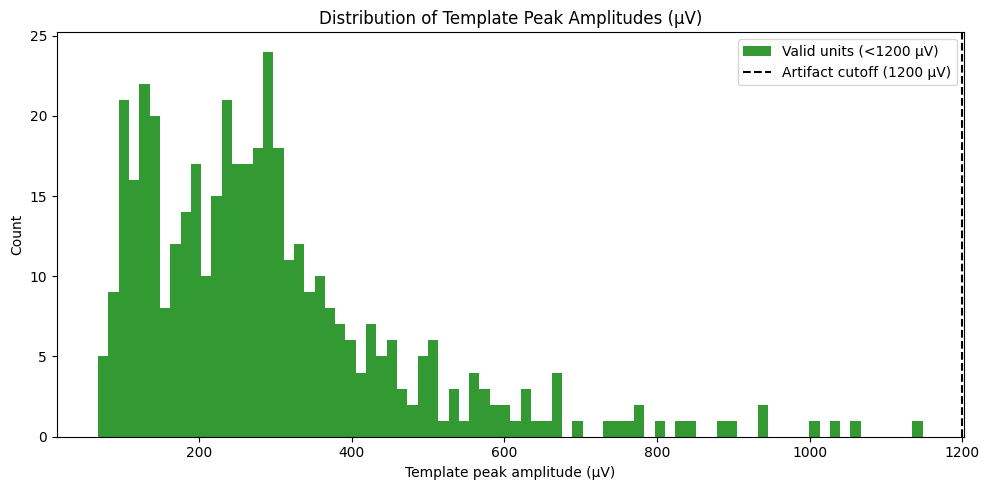


=== AMPLITUDE DISTRIBUTION SUMMARY ===
Total units: 428
Valid units (<1200 µV): 428
Artifact units (≥1200 µV): 0
Median amplitude (valid units): 260.47 µV
Max amplitude (valid units): 1148.16 µV

Artifact units: [] 


In [38]:
# ============================================================
# AMPLITUDE DISTRIBUTION + ARTIFACT UNIT DETECTION (µV)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
amp_cutoff_uv = 1200  ##############################################################################################################################################################################################
# ↑↑↑ Kevin edits this ONE value. Everything else depends on it.

# ------------------------------------------------------------
# BUILD AMPLITUDE ARRAY
# ------------------------------------------------------------
amps = np.array([unit_amp[uid] for uid in sorting.unit_ids])

# Masks
artifact_mask = amps >= amp_cutoff_uv
valid_mask = amps < amp_cutoff_uv

# Extract values
amps_valid = amps[valid_mask]
amps_artifact = amps[artifact_mask]

# ------------------------------------------------------------
# PLOT HISTOGRAM
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(amps_valid, bins=80, color='green', alpha=0.8,
         label=f'Valid units (<{amp_cutoff_uv} µV)')
if np.any(artifact_mask):
    plt.hist(amps_artifact, bins=40, color='red', alpha=0.8,
             label=f'Artifact units (≥{amp_cutoff_uv} µV)')

plt.axvline(amp_cutoff_uv, color='black', linestyle='--', linewidth=1.5,
            label=f'Artifact cutoff ({amp_cutoff_uv} µV)')

plt.xlabel("Template peak amplitude (µV)")
plt.ylabel("Count")
plt.title("Distribution of Template Peak Amplitudes (µV)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# UPDATE ARTIFACT + VALID UNIT LISTS FOR QC PIPELINE
# ------------------------------------------------------------
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]
valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]

print("\n=== AMPLITUDE DISTRIBUTION SUMMARY ===")
print(f"Total units: {len(amps)}")
print(f"Valid units (<{amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥{amp_cutoff_uv} µV): {len(artifact_units)}")
print(f"Median amplitude (valid units): {np.median(amps_valid):.2f} µV")
print(f"Max amplitude (valid units): {np.max(amps_valid):.2f} µV")

print("\nArtifact units:", artifact_units[:20], "..." if len(artifact_units) > 20 else "")

# ------------------------------------------------------------
# MODULE OUTPUT: AMPLITUDE QC LABELS
# ------------------------------------------------------------
qc_amp = {}
for uid in sorting.unit_ids:
    if uid in artifact_units:
        qc_amp[uid] = "FAIL_AMP"
    else:
        qc_amp[uid] = "PASS_AMP"


In [65]:
# ============================================================
# PHY "Amplitude" FILTER USING cluster_info.tsv
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
phy_amp_cutoff = 10.2  ###################################################################################################################################################################################################################
# ↑↑↑ Kevin edits this ONE value. Everything else depends on it.

# ------------------------------------------------------------
# LOAD PHY CLUSTER INFO
# ------------------------------------------------------------
cluster_info_path = kilosort_path / "cluster_info.tsv"
ci = pd.read_csv(cluster_info_path, sep='\t')

# Build dict: KS cluster id -> Phy "Amplitude" value (the column you circled)
phy_amp_from_info = {
    int(row["id"]): float(row["Amplitude"])
    for _, row in ci.iterrows()
}

# ------------------------------------------------------------
# CLASSIFY UNITS BASED ON PHY AMPLITUDE
# ------------------------------------------------------------
phy_valid_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) >= phy_amp_cutoff
]

phy_artifact_units = [
    uid for uid in sorting.unit_ids
    if phy_amp_from_info.get(int(uid), 0.0) < phy_amp_cutoff
]

print("\n=== PHY Amplitude FILTER (from cluster_info.tsv) ===")
print(f"Valid units (Amplitude >= {phy_amp_cutoff}): {len(phy_valid_units)}")
print(f"Artifact units (Amplitude < {phy_amp_cutoff}): {len(phy_artifact_units)}")

# ------------------------------------------------------------
# MODULE OUTPUT: PHY AMPLITUDE QC LABELS
# ------------------------------------------------------------
qc_phy_amp = {}
for uid in sorting.unit_ids:
    if uid in phy_artifact_units:
        qc_phy_amp[uid] = "FAIL_PHYAMP"
    else:
        qc_phy_amp[uid] = "PASS_PHYAMP"



=== PHY Amplitude FILTER (from cluster_info.tsv) ===
Valid units (Amplitude >= 10.2): 252
Artifact units (Amplitude < 10.2): 176


Computing SNR and amplitude QC using Kilosort templates...

=== AMPLITUDE FILTER RESULTS ===
Valid units (< 1600 µV): 428
Artifact units (≥ 1600 µV): 0

=== SNR QC SUMMARY (best channel) ===
Median noise (µV): 47.999061584472656
Median template peak (µV): 260.47145080566406
Median SNR: 5.521812157366057

First 5 units:
Unit 0: best_ch=9, amp=334.6 µV, noise=52.5 µV, SNR=6.37
Unit 1: best_ch=2, amp=94.5 µV, noise=52.8 µV, SNR=1.79
Unit 2: best_ch=4, amp=99.6 µV, noise=51.5 µV, SNR=1.93
Unit 3: best_ch=2, amp=189.0 µV, noise=52.8 µV, SNR=3.58
Unit 4: best_ch=96, amp=371.8 µV, noise=47.2 µV, SNR=7.88


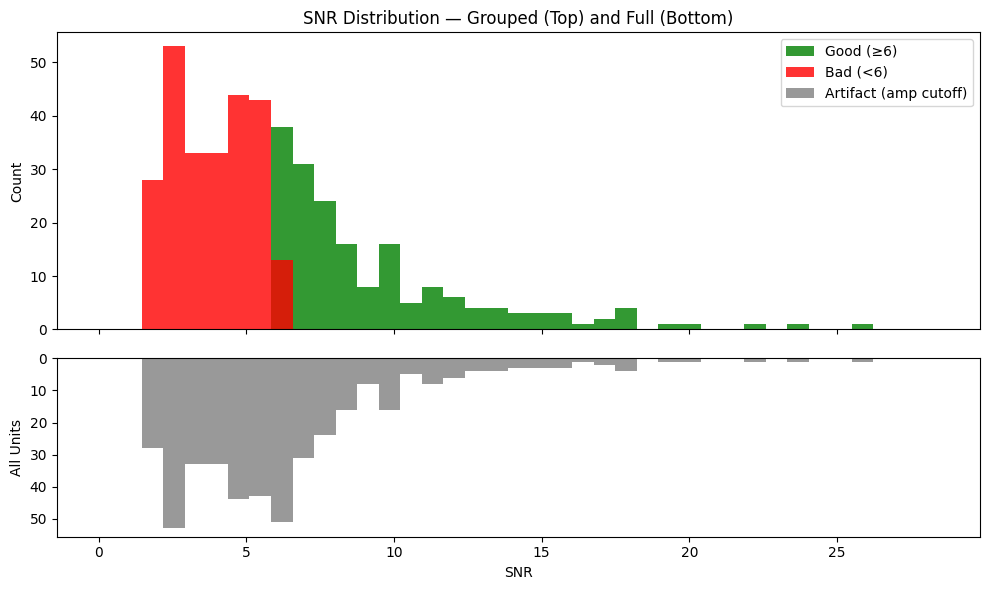

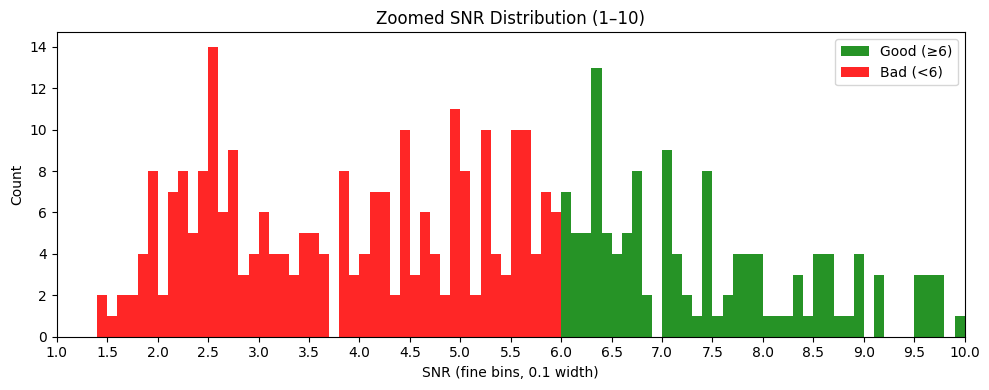


=== 10 UNITS AROUND MEDIAN SNR (median=5.52) ===
Unit 138: SNR=5.44, amp=256.9 µV, noise=47.3 µV, best_ch=225
Unit 165: SNR=5.47, amp=268.3 µV, noise=49.0 µV, best_ch=324
Unit 424: SNR=5.50, amp=265.5 µV, noise=48.2 µV, best_ch=377
Unit 88: SNR=5.52, amp=275.6 µV, noise=50.0 µV, best_ch=25
Unit 341: SNR=5.52, amp=268.3 µV, noise=48.6 µV, best_ch=360
Unit 139: SNR=5.52, amp=256.3 µV, noise=46.4 µV, best_ch=222
Unit 238: SNR=5.52, amp=274.4 µV, noise=49.7 µV, best_ch=49
Unit 325: SNR=5.53, amp=277.4 µV, noise=50.2 µV, best_ch=352
Unit 115: SNR=5.53, amp=261.5 µV, noise=47.3 µV, best_ch=121
Unit 15: SNR=5.55, amp=247.0 µV, noise=44.5 µV, best_ch=290

=== SNR QC CLASSIFICATION ===
SNR good units (≥6): 181
SNR bad units (<6): 247
Artifact units (amp ≥ 1600 µV): 0

First 5 SNR-good units: [np.int64(0), np.int64(4), np.int64(21), np.int64(22), np.int64(23)]
First 5 SNR-bad units: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6)]
First 5 artifact units: []


In [66]:
# ============================================================
# CELL 4 — SNR + TEMPLATE AMPLITUDE QC (KILOSORT TEMPLATES)
# ============================================================

print("Computing SNR and amplitude QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
amp_cutoff_uv = 1600  ###########################################################################################################################################################################################################
snr_threshold = 6 ###########################################################################################################################################################################################################
# ↑↑↑ Kevin edits these ONE TIME. Everything else depends on them.

# ------------------------------------------------------------
# COMPUTE TEMPLATE AMPLITUDE, NOISE, SNR
# ------------------------------------------------------------

unit_best_ch = {}
unit_amp = {}
unit_noise = {}
unit_snr = {}

for i, uid in enumerate(sorting.unit_ids):

    templ = ks_templates_unwhitened[i]    # <-- Kilosort template (unwhitened)

    # Best channel = most negative peak
    neg_peaks = -np.min(templ, axis=0)
    best_ch = int(np.argmax(neg_peaks))
    neg_peak = float(neg_peaks[best_ch])

    # Noise from SI
    noise_best = float(noise[best_ch])
    snr = neg_peak / noise_best if noise_best > 0 else np.nan

    unit_best_ch[uid] = best_ch
    unit_amp[uid] = neg_peak
    unit_noise[uid] = noise_best
    unit_snr[uid] = snr

# ------------------------------------------------------------
# FILTER ARTIFACT UNITS BY TEMPLATE AMPLITUDE
# ------------------------------------------------------------

valid_units = [uid for uid in sorting.unit_ids if unit_amp[uid] < amp_cutoff_uv]
artifact_units = [uid for uid in sorting.unit_ids if unit_amp[uid] >= amp_cutoff_uv]

print("\n=== AMPLITUDE FILTER RESULTS ===")
print(f"Valid units (< {amp_cutoff_uv} µV): {len(valid_units)}")
print(f"Artifact units (≥ {amp_cutoff_uv} µV): {len(artifact_units)}")

# ------------------------------------------------------------
# SUMMARY STATISTICS
# ------------------------------------------------------------

amps_all = np.array(list(unit_amp.values()))
snrs_all = np.array(list(unit_snr.values()))
noise_all = np.array(list(unit_noise.values()))

print("\n=== SNR QC SUMMARY (best channel) ===")
print("Median noise (µV):", float(np.median(noise_all)))
print("Median template peak (µV):", float(np.median(amps_all)))
print("Median SNR:", float(np.nanmedian(snrs_all)))

print("\nFirst 5 units:")
for uid in sorting.unit_ids[:5]:
    print(f"Unit {uid}: best_ch={unit_best_ch[uid]}, amp={unit_amp[uid]:.1f} µV, "
          f"noise={unit_noise[uid]:.1f} µV, SNR={unit_snr[uid]:.2f}")

# ------------------------------------------------------------
# TWO-PART SNR HISTOGRAM
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad  = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] <  snr_threshold])
snr_artifact = np.array([unit_snr[uid] for uid in artifact_units])

snr_all = np.array([unit_snr[uid] for uid in sorting.unit_ids])

bins = np.linspace(0, max(snr_all) * 1.1, 40)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 0.6]}
)

ax_top.hist(snr_good, bins=bins, color='green', alpha=0.8, label=f'Good (≥{snr_threshold})')
ax_top.hist(snr_bad,  bins=bins, color='red',   alpha=0.8, label=f'Bad (<{snr_threshold})')
ax_top.hist(snr_artifact, bins=bins, color='gray', alpha=0.8, label='Artifact (amp cutoff)')

ax_top.set_ylabel("Count")
ax_top.set_title("SNR Distribution — Grouped (Top) and Full (Bottom)")
ax_top.legend(loc='upper right')

ax_bottom.hist(snr_all, bins=bins, color='black', alpha=0.4)
ax_bottom.invert_yaxis()
ax_bottom.set_ylabel("All Units")
ax_bottom.set_xlabel("SNR")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ZOOMED SNR HISTOGRAM (1–10)
# ------------------------------------------------------------

snr_good = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] >= snr_threshold])
snr_bad  = np.array([unit_snr[uid] for uid in valid_units if unit_snr[uid] <  snr_threshold])

bins = np.arange(1, 10.1, 0.1)

plt.figure(figsize=(10, 4))
plt.hist(snr_good, bins=bins, color='green', alpha=0.85, label=f'Good (≥{snr_threshold})')
plt.hist(snr_bad,  bins=bins, color='red',   alpha=0.85, label=f'Bad (<{snr_threshold})')

plt.xticks(np.arange(1, 11, 0.5))
plt.xlim(1, 10)

plt.xlabel("SNR (fine bins, 0.1 width)")
plt.ylabel("Count")
plt.title("Zoomed SNR Distribution (1–10)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================================
# UNITS AROUND THE MEDIAN SNR (MODULAR)
# ============================================================

around_n = 10  ##############################################################################################################
# ↑↑↑ Kevin-tunable parameter: how many units to print around the median SNR

# Build list of (uid, snr) for valid units only
snr_list = [(uid, unit_snr[uid]) for uid in valid_units]

# Sort by SNR
snr_sorted = sorted(snr_list, key=lambda x: x[1])

# Compute median SNR value
median_snr_val = np.median([unit_snr[uid] for uid in valid_units])

# Find index of the unit whose SNR is closest to the median
median_idx = min(
    range(len(snr_sorted)),
    key=lambda i: abs(snr_sorted[i][1] - median_snr_val)
)

# Determine slice around the median
start = max(0, median_idx - around_n // 2)
end = min(len(snr_sorted), start + around_n)

print(f"\n=== {end - start} UNITS AROUND MEDIAN SNR (median={median_snr_val:.2f}) ===")
for uid, snr_val in snr_sorted[start:end]:
    print(
        f"Unit {uid}: "
        f"SNR={snr_val:.2f}, "
        f"amp={unit_amp[uid]:.1f} µV, "
        f"noise={unit_noise[uid]:.1f} µV, "
        f"best_ch={unit_best_ch[uid]}"
    )


# ------------------------------------------------------------
# CLASSIFY UNITS BY SNR (USING snr_threshold)
# ------------------------------------------------------------

snr_good_units = [uid for uid in valid_units if unit_snr[uid] >= snr_threshold]
snr_bad_units  = [uid for uid in valid_units if unit_snr[uid] <  snr_threshold]

print("\n=== SNR QC CLASSIFICATION ===")
print(f"SNR good units (≥{snr_threshold}): {len(snr_good_units)}")
print(f"SNR bad units (<{snr_threshold}): {len(snr_bad_units)}")
print(f"Artifact units (amp ≥ {amp_cutoff_uv} µV): {len(artifact_units)}")

print("\nFirst 5 SNR-good units:", snr_good_units[:5])
print("First 5 SNR-bad units:", snr_bad_units[:5])
print("First 5 artifact units:", artifact_units[:5])

# ------------------------------------------------------------
# MODULE OUTPUT: SNR QC LABELS
# ------------------------------------------------------------

qc_snr = {}

for uid in sorting.unit_ids:
    if uid in artifact_units:
        qc_snr[uid] = "SKIP_SNR_ARTIFACT"
    elif uid in snr_good_units:
        qc_snr[uid] = "PASS_SNR"
    else:
        qc_snr[uid] = "FAIL_SNR"


In [67]:
# ============================================================
# CELL 4.5 — POSITIVE DEFLECTION QC (KILOSORT TEMPLATES ONLY)
# ============================================================

print("Computing positive deflection QC using Kilosort templates...")

# ------------------------------------------------------------
# TUNABLE PARAMETER (ONLY EDIT HERE)
# ------------------------------------------------------------
pos_ratio_threshold = 0.3  #############################################################################################################################################################################################

# ------------------------------------------------------------
# COMPUTE POSITIVE / NEGATIVE PEAK RATIOS
# ------------------------------------------------------------

unit_pos_ratio = {}
unit_pos_amp = {}
unit_neg_amp = {}

for uid in sorting.unit_ids:

    main_ch_id = phy_best_ch_id[uid]

    if main_ch_id not in phys_to_template_index:
        unit_pos_ratio[uid] = np.inf
        unit_pos_amp[uid] = 0.0
        unit_neg_amp[uid] = 0.0
        continue

    main_idx = phys_to_template_index[main_ch_id]
    trace = ks_templates[uid][:, main_idx]

    neg = abs(np.min(trace))
    pos = abs(np.max(trace))

    unit_neg_amp[uid] = float(neg)
    unit_pos_amp[uid] = float(pos)
    unit_pos_ratio[uid] = float(pos / neg) if neg > 0 else np.inf

# ------------------------------------------------------------
# CLASSIFY UNITS BASED ON POSITIVE BUMP RATIO
# ------------------------------------------------------------

pos_bad_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] >= pos_ratio_threshold]
pos_good_units = [uid for uid in sorting.unit_ids if unit_pos_ratio[uid] <  pos_ratio_threshold]

print("\n=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===")
print(f"BAD units (pos/neg >= {pos_ratio_threshold}): {len(pos_bad_units)}")
print(f"GOOD units (pos/neg <  {pos_ratio_threshold}): {len(pos_good_units)}")

# ------------------------------------------------------------
# MODULE OUTPUT: POSITIVE BUMP QC LABELS
# ------------------------------------------------------------

qc_pos = {}
for uid in sorting.unit_ids:
    qc_pos[uid] = "FAIL_POS" if uid in pos_bad_units else "PASS_POS"


Computing positive deflection QC using Kilosort templates...

=== POSITIVE DEFLECTION QC (PHY MAIN CHANNEL ONLY) ===
BAD units (pos/neg >= 0.3): 336
GOOD units (pos/neg <  0.3): 92


In [43]:
# ============================================================
# CELL 5 — SLIM + SAFE ISI + ACG QC
# ============================================================

import numpy as np

print("Computing ISI violations + ACG (memory‑safe)...")

# ------------------------------------------------------------
# TUNABLE PARAMETERS (ONLY EDIT THESE)
# ------------------------------------------------------------
rp_ms = 2.0             ##################################################################################################################################################################################################################
isi_threshold = 0.01     ##################################################################################################################################################################################################################
# ↑↑↑ Kevin edits these ONE TIME. Everything else depends on them.

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
isi_metrics = {}
acg_metrics = {}

# ------------------------------------------------------------
# FUNCTIONS
# ------------------------------------------------------------
def compute_rpv(st_sec, rp_ms=1.0):
    if st_sec.size < 2:
        return np.nan
    isis = np.diff(st_sec)
    return np.sum(isis < (rp_ms / 1000.0)) / len(isis)

def compute_acg(st_sec, bin_ms=1.0, max_lag_ms=50.0):
    if st_sec.size < 2:
        return np.array([0.0]), np.array([0])

    t_ms = st_sec * 1000.0
    diffs = []
    j0 = 0

    for i in range(len(t_ms)):
        t0 = t_ms[i]

        while j0 < len(t_ms) and t_ms[j0] < t0 - max_lag_ms:
            j0 += 1

        j = j0
        while j < len(t_ms) and t_ms[j] <= t0 + max_lag_ms:
            dt = t_ms[j] - t0
            if dt != 0:
                diffs.append(dt)
            j += 1

    diffs = np.array(diffs)
    bins = np.arange(-max_lag_ms, max_lag_ms + bin_ms, bin_ms)
    acg_counts, edges = np.histogram(diffs, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2.0
    return centers, acg_counts

# ------------------------------------------------------------
# LOOP THROUGH UNITS
# ------------------------------------------------------------
fs = recording.sampling_frequency

for uid in sorting.unit_ids:

    if uid in artifact_units:
        continue

    st_samples = sorting.get_unit_spike_train(uid)
    if st_samples.size < 2:
        isi_metrics[uid] = np.nan
        acg_metrics[uid] = (np.array([0]), np.array([0]))
        continue

    st_sec = st_samples / fs

    rpv = compute_rpv(st_sec, rp_ms=rp_ms)
    isi_metrics[uid] = rpv

    acg_x, acg_y = compute_acg(st_sec)
    acg_metrics[uid] = (acg_x, acg_y)

# ------------------------------------------------------------
# CLASSIFICATION
# ------------------------------------------------------------
good_isi_units = [uid for uid in isi_metrics if isi_metrics[uid] <  isi_threshold]
bad_isi_units  = [uid for uid in isi_metrics if isi_metrics[uid] >= isi_threshold]

print("\n=== ISI QC SUMMARY ===")
print(f"Good ISI units (<{isi_threshold*100:.1f}% RPV): {len(good_isi_units)}")
print(f"Bad ISI units (≥{isi_threshold*100:.1f}% RPV): {len(bad_isi_units)}")

print("\nFirst 5 ISI metrics:")
for uid in list(isi_metrics.keys())[:5]:
    print(f"Unit {uid}: RPV={isi_metrics[uid]:.4f}")

# ------------------------------------------------------------
# MODULE OUTPUT: ISI QC LABELS
# ------------------------------------------------------------
qc_isi = {}
for uid in sorting.unit_ids:
    if uid not in isi_metrics:
        qc_isi[uid] = "SKIP_ISI"
    elif np.isnan(isi_metrics[uid]):
        qc_isi[uid] = "SKIP_ISI"
    elif isi_metrics[uid] < isi_threshold:
        qc_isi[uid] = "PASS_ISI"
    else:
        qc_isi[uid] = "FAIL_ISI"


Computing ISI violations + ACG (memory‑safe)...

=== ISI QC SUMMARY ===
Good ISI units (<1.0% RPV): 278
Bad ISI units (≥1.0% RPV): 150

First 5 ISI metrics:
Unit 0: RPV=0.0000
Unit 1: RPV=0.0038
Unit 2: RPV=0.0424
Unit 3: RPV=0.0022
Unit 4: RPV=0.0308


In [68]:
# ============================================================
# FINAL QC TABLE + VERDICT (MODULAR)
# ============================================================

import pandas as pd

qc_rows = []

for uid in sorting.unit_ids:

    # Pull module labels
    amp_label     = qc_amp.get(uid, "NA_AMP")
    phy_label     = qc_phy_amp.get(uid, "NA_PHYAMP")
    snr_label     = qc_snr.get(uid, "NA_SNR")
    isi_label     = qc_isi.get(uid, "NA_ISI")
    pos_label     = qc_pos.get(uid, "NA_POS")

    # Auto-eliminate if PHY amplitude fails
    if phy_label == "FAIL_PHYAMP":
        verdict = "REJECT"
        qc_rows.append({
            "unit": uid,
            "AMP": amp_label,
            "PHY_AMP": phy_label,
            "SNR": snr_label,
            "ISI": isi_label,
            "POS": pos_label,
            "fail_count": "AUTO_FAIL_PHY",
            "verdict": verdict
        })
        continue

    # Count failures among the remaining QC modules
    labels = [amp_label, snr_label, isi_label, pos_label]
    fail_count = sum(lbl.startswith("FAIL") for lbl in labels)

    # Verdict logic
    if fail_count == 0:
        verdict = "GOOD"
    elif fail_count == 1:
        verdict = "CHECK"
    else:
        verdict = "REJECT"

    qc_rows.append({
        "unit": uid,
        "AMP": amp_label,
        "PHY_AMP": phy_label,
        "SNR": snr_label,
        "ISI": isi_label,
        "POS": pos_label,
        "fail_count": fail_count,
        "verdict": verdict
    })

# Build DataFrame
qc_df = pd.DataFrame(qc_rows).sort_values("unit").reset_index(drop=True)

print("\n=== FINAL QC VERDICT COUNTS ===")
print(qc_df["verdict"].value_counts())

qc_df.head(20)



=== FINAL QC VERDICT COUNTS ===
verdict
REJECT    291
CHECK      87
GOOD       50
Name: count, dtype: int64


,unit,AMP,PHY_AMP,SNR,ISI,POS,fail_count,verdict
0,0,PASS_AMP,PASS_PHYAMP,PASS_SNR,PASS_ISI,FAIL_POS,1,CHECK
1,1,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,AUTO_FAIL_PHY,REJECT
2,2,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,FAIL_ISI,FAIL_POS,AUTO_FAIL_PHY,REJECT
3,3,PASS_AMP,FAIL_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,AUTO_FAIL_PHY,REJECT
4,4,PASS_AMP,PASS_PHYAMP,PASS_SNR,FAIL_ISI,FAIL_POS,2,REJECT
5,5,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,2,REJECT
6,6,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,2,REJECT
7,7,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,FAIL_POS,2,REJECT
8,8,PASS_AMP,PASS_PHYAMP,FAIL_SNR,FAIL_ISI,FAIL_POS,3,REJECT
9,9,PASS_AMP,PASS_PHYAMP,FAIL_SNR,PASS_ISI,PASS_POS,1,CHECK


In [59]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
    else:
        print(row.to_string(index=False))
        
def show_qc_for_unit(unit_id):
    row = qc_df[qc_df["unit"] == unit_id]
    if row.empty:
        print(f"Unit {unit_id} not found in QC table.")
        return
    
    r = row.iloc[0]
    print(f"Unit {unit_id} QC breakdown:")
    print(f"  AMP:       {r.AMP}")
    print(f"  PHY_AMP:   {r.PHY_AMP}")
    print(f"  SNR:       {r.SNR}")
    print(f"  ISI:       {r.ISI}")
    print(f"  POS:       {r.POS}")
    print(f"  Fail count:{r.fail_count}")
    print(f"  Verdict:   {r.verdict}")


show_qc_for_unit(23)

Unit 23 QC breakdown:
  AMP:       PASS_AMP
  PHY_AMP:   PASS_PHYAMP
  SNR:       PASS_SNR
  ISI:       FAIL_ISI
  POS:       PASS_POS
  Fail count:1
  Verdict:   CHECK


In [69]:
# ============================================================
# REBUILD cluster_group.tsv FROM QC VERDICTS (CHECK → GOOD)
# ============================================================

import pandas as pd

cluster_group_path = kilosort_path / "cluster_group.tsv"

rows = []

for row in qc_df.itertuples():
    uid = int(row.unit)
    verdict = row.verdict

    # Map QC verdict → Phy label
    if verdict == "REJECT":
        group = "noise"      # Ctrl+N equivalent
    elif verdict == "CHECK":
        group = "good"       # CHECK now treated as GOOD
    elif verdict == "GOOD":
        group = "good"
    else:
        group = "good"

    rows.append({"cluster_id": uid, "group": group})

cg_new = pd.DataFrame(rows)
cg_new.to_csv(cluster_group_path, sep="\t", index=False)

print("Rebuilt cluster_group.tsv with", len(cg_new), "rows.")
print("CHECK units are now labeled as GOOD in Phy.")


Rebuilt cluster_group.tsv with 428 rows.
CHECK units are now labeled as GOOD in Phy.
